In [1]:
%matplotlib widget
from lines import REDUC_LINES
from corr import REDSHIFT, SPECTRALDATA, CONTINUUM_SUBSTRACT
from new_lines import fitting_lines, a_ratio_dist, save_data, fit_auroral_new, save_data_auroral_MC

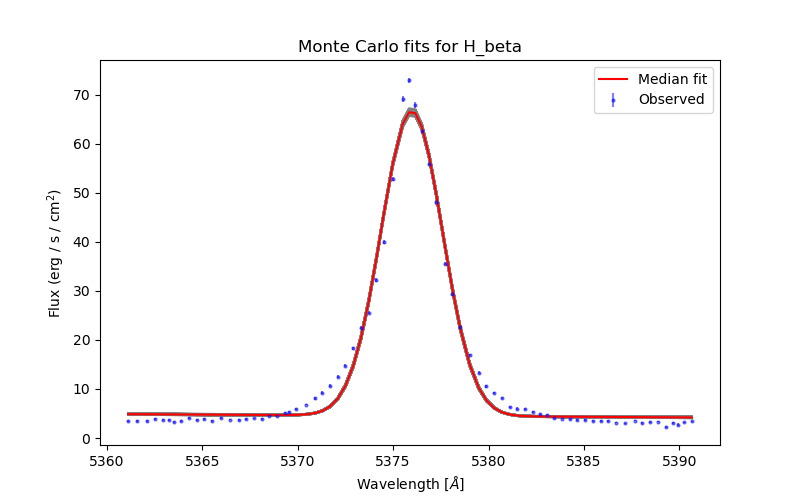

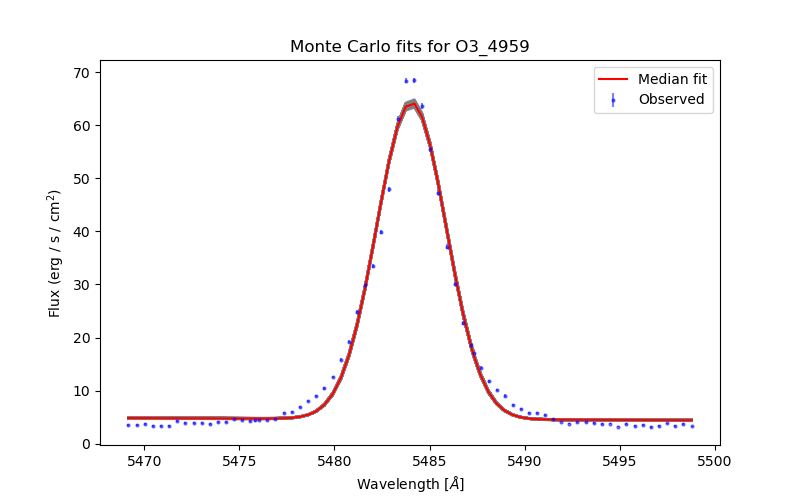

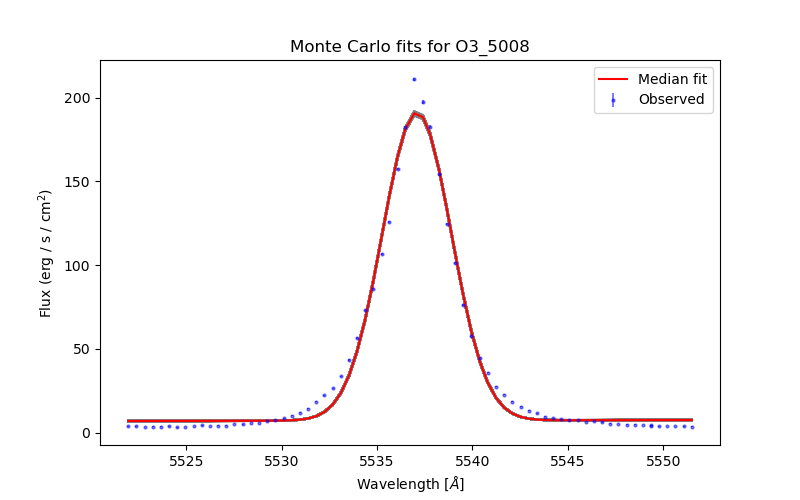

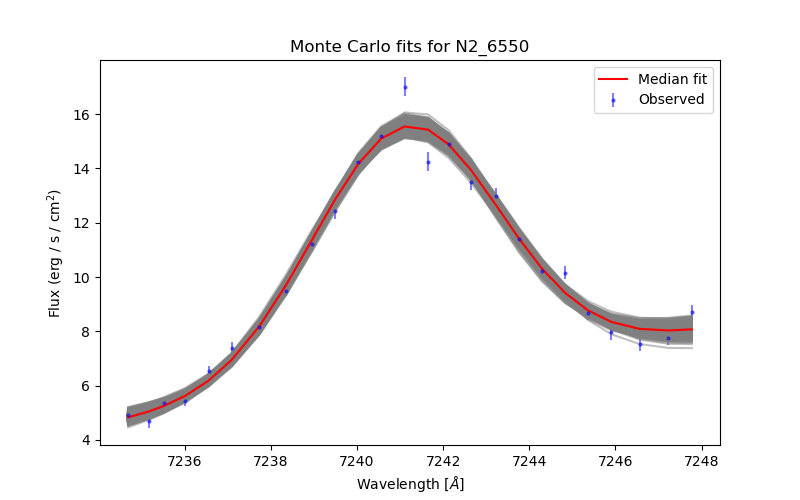

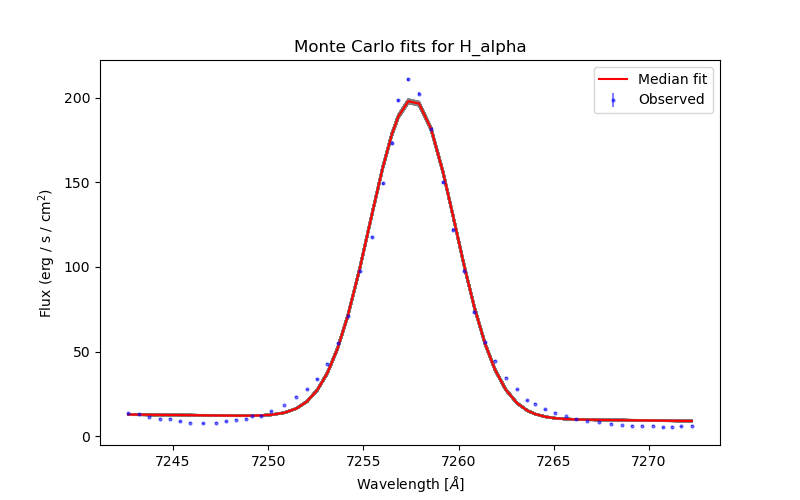

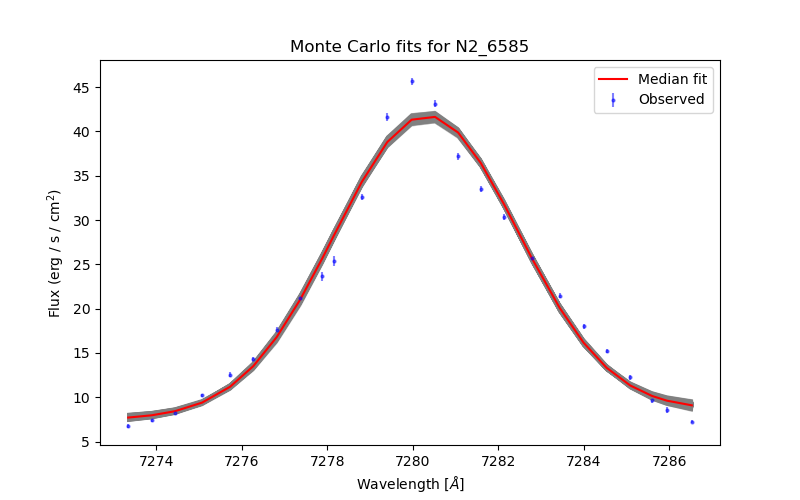

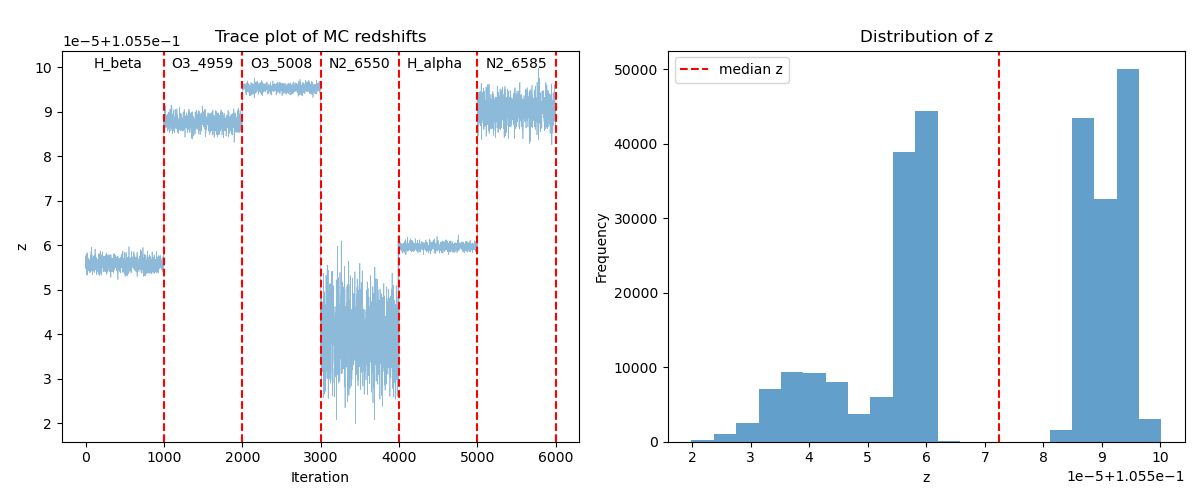

New redshift calculated for no_very_flats,z = 0.10557245579790175
Executed reset_redshift in 54.3302s
New redshift for J0020+0030,z = 0.10557245579790175


In [2]:
J0020_SPECTRA= {
    'DIR':'/Users/javieratoro/Desktop/thesis/BAADE_DATA/testing/10-J0020/',
    'FILES': ['no_very_flats/J0020_NO_VERY_FLATS_tellcorr.fits'],
     'redshift': 0.106,
     'names':['J0020+0030'],
     'mass':9.6
}
J0020 = SPECTRALDATA(J0020_SPECTRA)
Z = REDSHIFT(J0020)

In [4]:
red = REDUC_LINES(J0020)

Reading data for J0020
Using MW dust + Balmer abs corrected and continuum substracted data


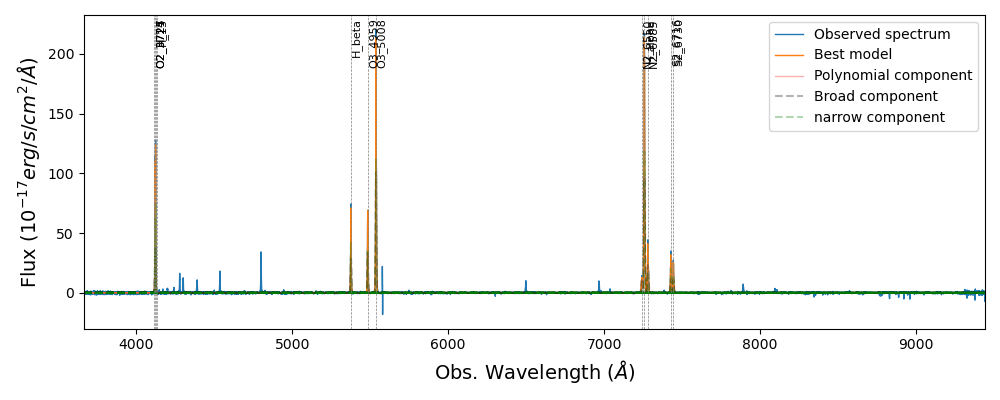

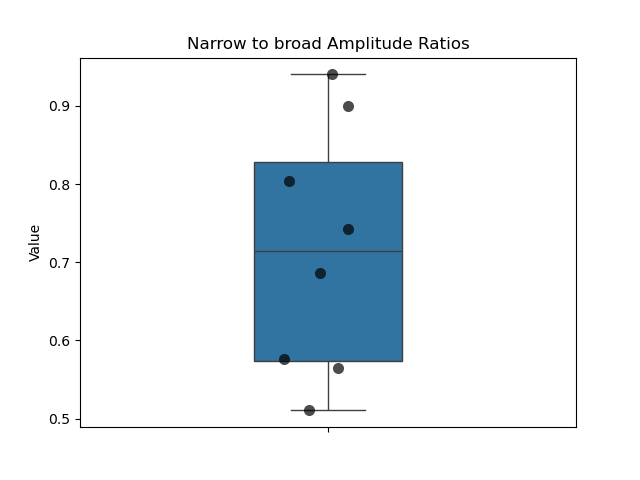

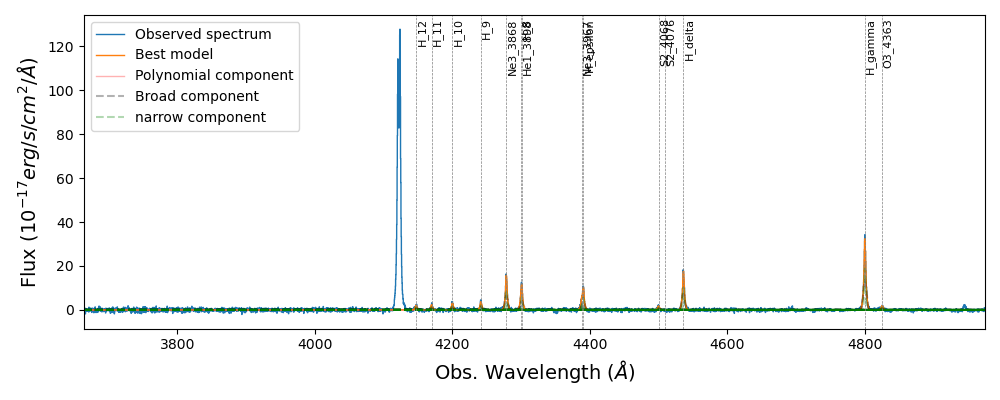

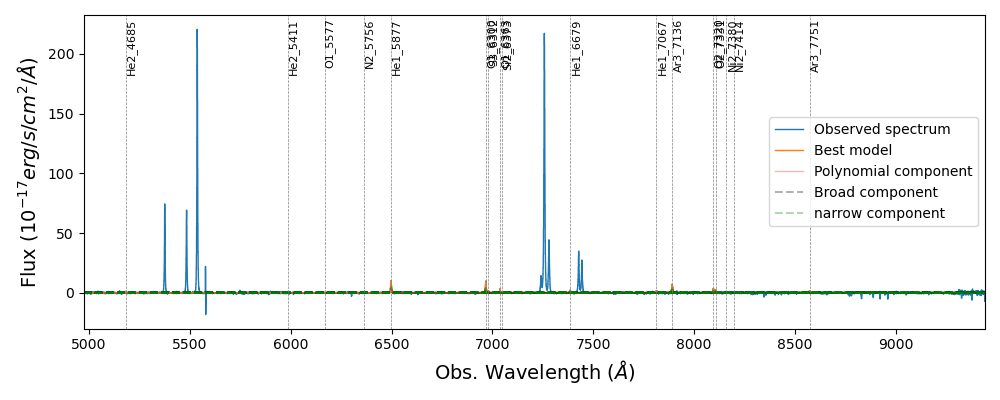

In [5]:
linelist = red.spectra.linelist_dict
bright_lines = ['H_14', 'H_13', 'O2_3725', 'O2_3727', 'H_alpha', 'H_beta',
                'O3_5008', 'O3_4959', 'N2_6550', 'N2_6585',
                'S2_6716','S2_6730']

bright_dict = {k: v for k, v in linelist.items() if k in bright_lines}
faint_dict  = {k: v for k, v in linelist.items() if k not in bright_lines}

mask = (red.wave < 4500*(1+red.spectra.redshift))
wave1, flux1, sigma1 = red.wave[mask], red.flux[mask], red.sigma[mask]
wave2, flux2, sigma2 = red.wave[~mask], red.flux[~mask], red.sigma[~mask]

blue_lines_b = {k:v for k,v in bright_dict.items() if v < 4500}
red_lines_b  = {k:v for k,v in bright_dict.items() if v >= 4500}

blue_lines_f = {k:v for k,v in faint_dict.items() if v < 4500}
red_lines_f  = {k:v for k,v in faint_dict.items() if v >= 4500}

lines = red.spectra.linelist_dict
blue_lines = {k:v for k,v in lines.items() if v < 4500}
red_lines = {k:v for k,v in lines.items() if v >= 4500}


init = fitting_lines(red.wave, red.flux, red.sigma,
                    bright_dict,
                    z_init=red.spectra.redshift, plot=True,
                    nfev=1000, fit=None, A_ratio=None)
ratios = a_ratio_dist(init, plot=True)

out_blue = fitting_lines(wave1, flux1, sigma1,
                    blue_lines_f,
                    z_init=red.spectra.redshift, plot=True,
                    nfev=1000, fit=init, A_ratio=ratios)

out_red = fitting_lines(wave2, flux2, sigma2,
                    red_lines_f,
                    z_init=red.spectra.redshift,plot=True,
                    nfev=1000, fit=init, A_ratio=ratios)

In [7]:
save_data(red, 100)

Starting MC iteration
Saving in /Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/J0020/


,ID,mass,z_red,z_blue,name,flux,fluxerr,narrow_flux,narrow_fluxerr,broad_flux,broad_fluxerr
0,J0020+0030,9.6,0.10558,0.105593,H_14,12.651362,1.538543,3.514797,0.720869,9.126777,1.600121
1,J0020+0030,9.6,0.10558,0.105593,O2_3725,320.641047,14.824326,72.508938,12.236636,247.862342,4.310403
2,J0020+0030,9.6,0.10558,0.105593,O2_3727,335.446135,9.866272,100.635733,14.277423,234.723517,23.893429
3,J0020+0030,9.6,0.10558,0.105593,H_13,10.824050,0.924620,0.131679,0.345822,10.580298,1.040926
4,J0020+0030,9.6,0.10558,0.105593,H_12,6.832689,0.459645,2.081181,0.227996,4.748284,0.346833
5,J0020+0030,9.6,0.10558,0.105593,H_11,7.420866,0.475144,2.254992,0.226842,5.110288,0.376635
6,J0020+0030,9.6,0.10558,0.105593,H_10,9.793615,0.474374,2.975673,0.302719,6.824074,0.374077
7,J0020+0030,9.6,0.10558,0.105593,H_9,12.038725,0.495099,3.659186,0.356827,8.395537,0.403510
8,J0020+0030,9.6,0.10558,0.105593,Ne3_3868,51.364307,1.536544,15.568010,1.458957,35.756348,1.413867
9,J0020+0030,9.6,0.10558,0.105593,He1_3898,31.959463,1.349973,9.729406,0.960646,22.374211,1.104051


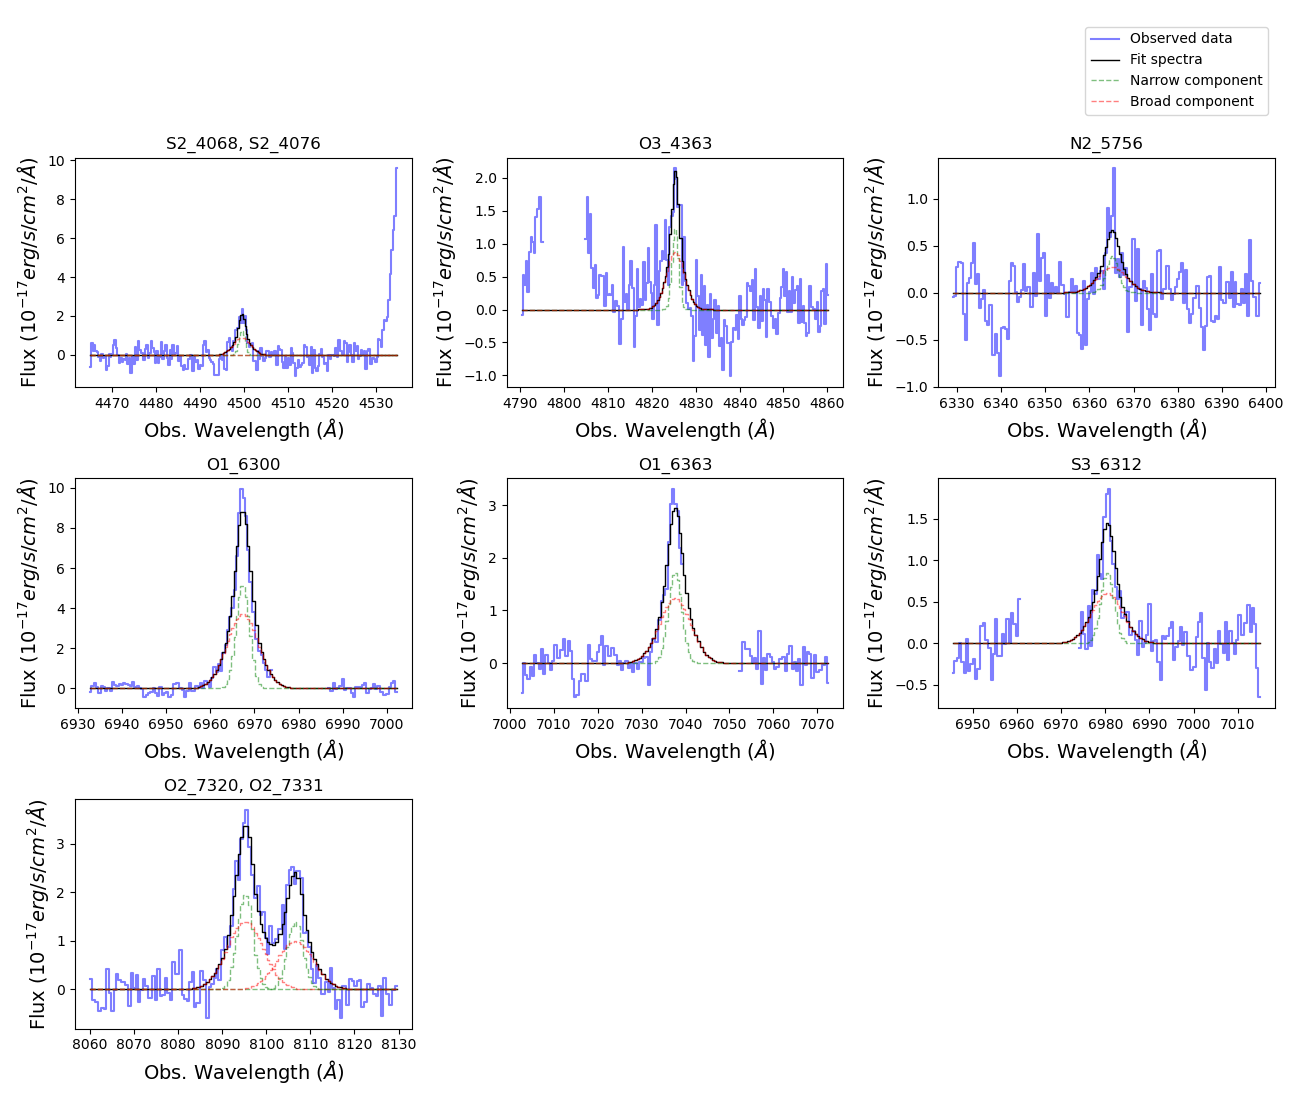

/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/new_lines.py:511: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  info = pd.concat([info, df], ignore_index=True)


In [6]:
a, b = fit_auroral_new(red, ratio=ratios, flux_=red.flux, showplot=True)
info, res = save_data_auroral_MC(red, ratio=ratios, num=100)

In [7]:
res

,ID,mass,z,name,flux,fluxerr,narrow_flux,narrow_fluxerr,broad_flux,broad_fluxerr
0,J0020+0030,9.6,0.105562,S2_4068,6.614312e+00,0.411627,2.227032e+00,0.138594,4.387280e+00,0.273033
1,J0020+0030,9.6,0.105562,O3_4363,6.845441e+00,0.387697,2.304853e+00,0.130537,4.540588e+00,0.257160
2,J0020+0030,9.6,0.105562,N2_5756,3.679892e+00,0.452191,1.379457e+00,0.169510,2.300435e+00,0.282681
3,J0020+0030,9.6,0.105562,O1_6300,5.249329e+01,0.445101,1.967782e+01,0.166852,3.281547e+01,0.278249
4,J0020+0030,9.6,0.105562,O1_6363,1.754075e+01,0.431856,6.575388e+00,0.161887,1.096536e+01,0.269969
5,J0020+0030,9.6,0.105562,S3_6312,8.601746e+00,0.387518,3.224481e+00,0.145266,5.377265e+00,0.242252
6,J0020+0030,9.6,0.105562,O2_7320,2.306752e+01,0.662301,8.647170e+00,0.248273,1.442035e+01,0.414029
7,J0020+0030,9.6,0.105562,O2_7331,1.634936e+01,0.700652,6.128779e+00,0.262649,1.022058e+01,0.438003
8,J0020+0030,9.6,0.105562,S2_4076,8.708468e-08,0.108932,2.932133e-08,0.036677,5.776335e-08,0.072255


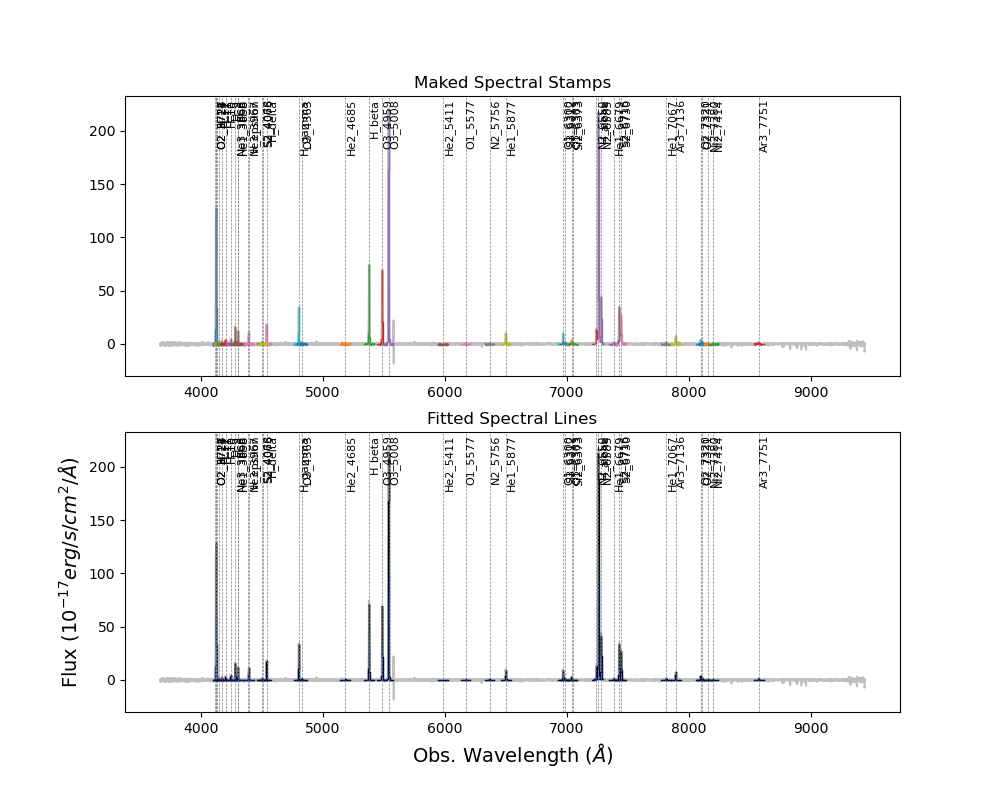

([<lmfit.model.ModelResult at 0x15d6f2350>,
 array(['H_12', 'H_11', 'H_10', 'H_9', 'Ne3_3868', 'H_delta', 'S2_4068',
        'S2_4076', 'H_gamma', 'O3_4363', 'He2_4685', 'H_beta', 'O3_4959',
        'O3_5008', 'He2_5411', 'O1_5577', 'N2_5756', 'He1_5877', 'O1_6300',
        'S3_6312', 'O1_6363', 'Si2_6373', 'N2_6550', 'He1_6679', 'S2_6716',
        'S2_6730', 'He1_7067', 'Ar3_7136', 'O2_7320', 'O2_7331',
        'Ni2_7380', 'Ni2_7414', 'Ar3_7751', 'H_alpha', 'He1_3898',
        'H_epsilon'], dtype=object))

In [6]:
red.fit_lines(red.wave, red.flux, showplot=True)

Performing dust correction for J0020
Extinction correction done! Using total curve.


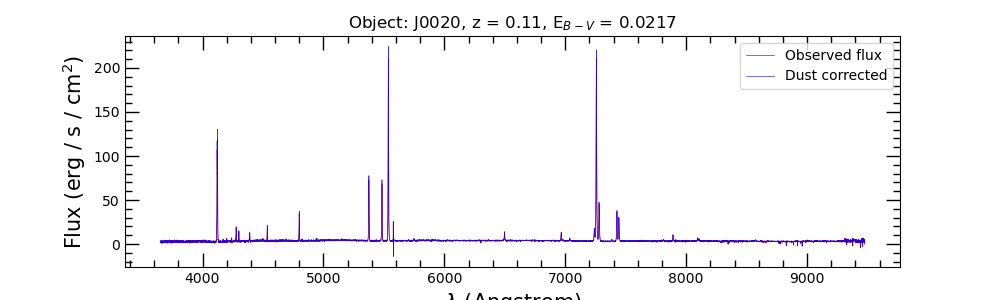

Saved figure at: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/dust/J0020/dcorr_J0020.pdf
Using MW dust + Balmer abs corrected and continuum substracted data


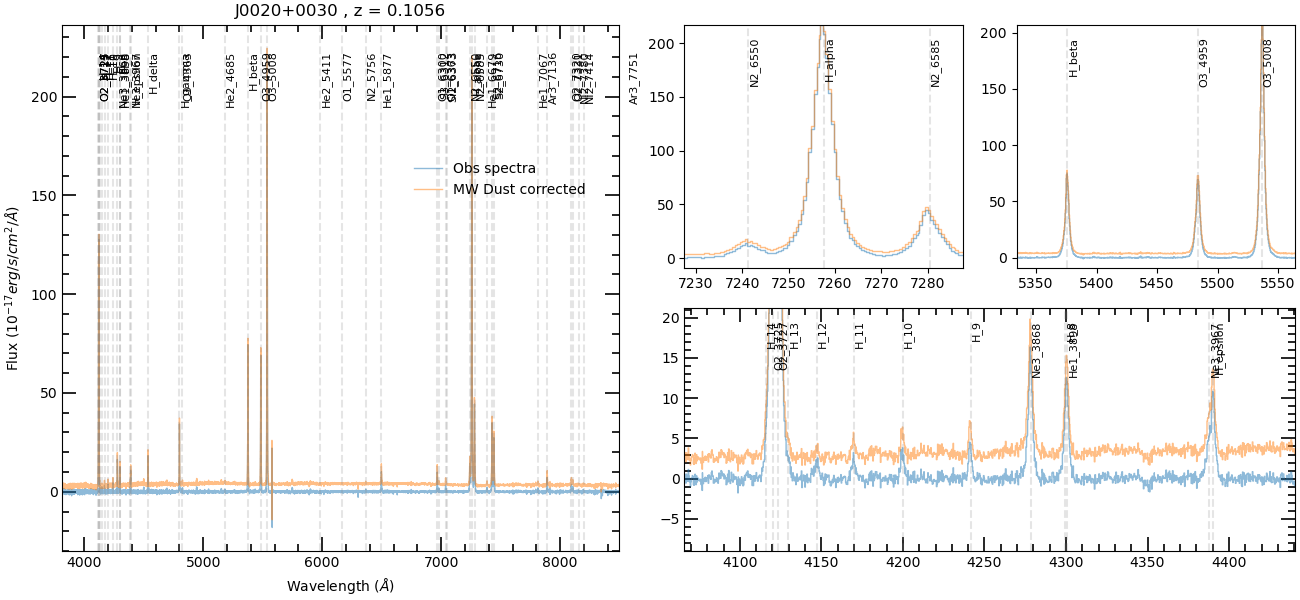

Saved MW dust corrected data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/dust/J0020/dcorr_J0020.csv
Executed MW_dust_corr in 0.8118s


In [3]:
MW_DUST_CORR(J0020, plot=True)

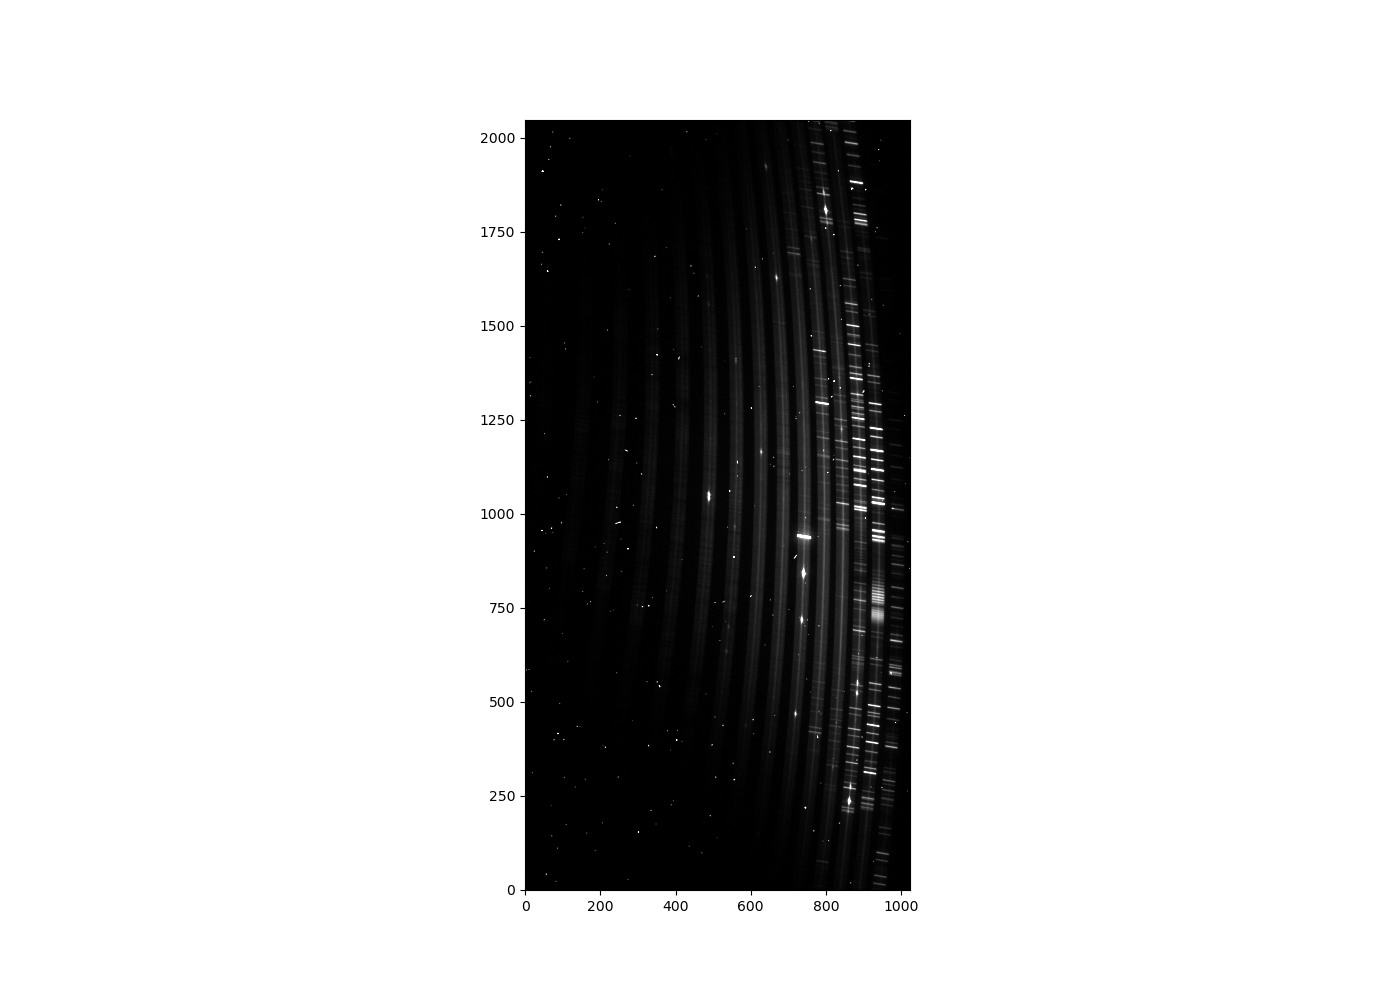

In [39]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
hdu = fits.open('/Users/javieratoro/Desktop/thesis/BAADE_DATA/testing/10-J0020/no_very_flats/Science/spec2d_mage0071-J0020+0030_MagE_20241108T024313.000.fits')
image = hdu[1].data
plt.figure(figsize=(14,10))
plt.imshow(image, vmin=0.1, vmax=500, origin='lower', cmap='grey')
plt.show()

In [17]:
hdu[1].data

array([[ 2.1128414e+00,  5.8632827e-01, -5.1096492e+00, ...,
        -5.2726960e-01,  1.1634573e+01,  1.3561952e+00],
       [ 7.2841331e-02, -8.5936718e+00,  2.0303509e+00, ...,
         1.5127304e+00, -2.6454270e+00, -1.7038047e+00],
       [ 6.1928415e+00, -5.5336719e+00, -4.0896492e+00, ...,
        -4.6072698e+00, -3.6654270e+00,  2.3761952e+00],
       ...,
       [ 1.1292841e+01,  4.6663284e+00,  4.0703506e+00, ...,
        -5.2726960e-01,  1.0614573e+01,  1.0536195e+01],
       [ 6.1928415e+00,  5.6863284e+00,  3.0503509e+00, ...,
         6.6127305e+00, -1.6254270e+00,  3.3619526e-01],
       [ 9.2528410e+00,  3.6463282e+00, -9.6491203e-03, ...,
         8.6527300e+00,  3.4745729e+00,  3.3619526e-01]], dtype='>f4')

Reading data for J0020
Using MW dust corrected data
Performing Balmer absorption correction for J0020


/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/corr.py:465: RuntimeWarning: divide by zero encountered in divide
  weights=1/self.sigma**2,


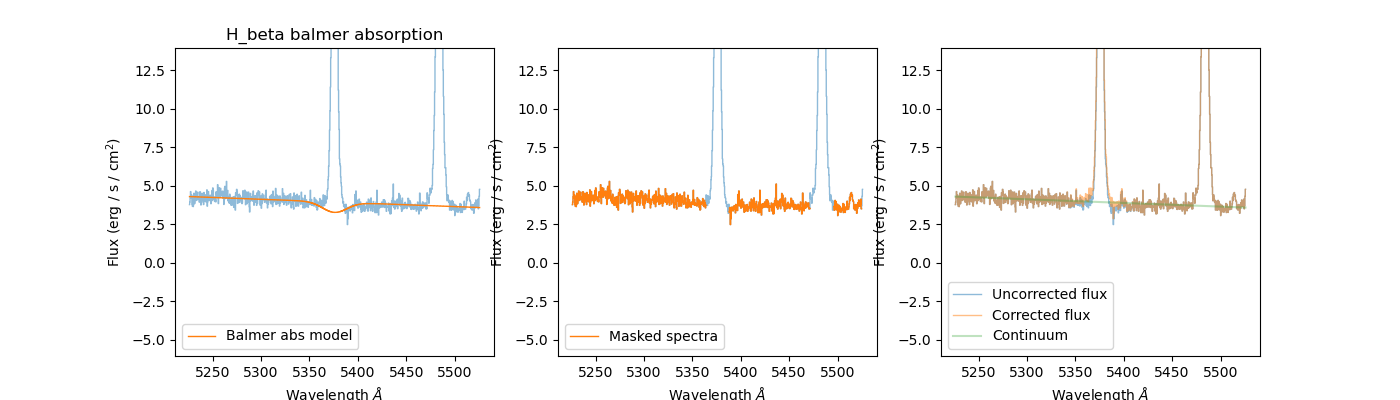

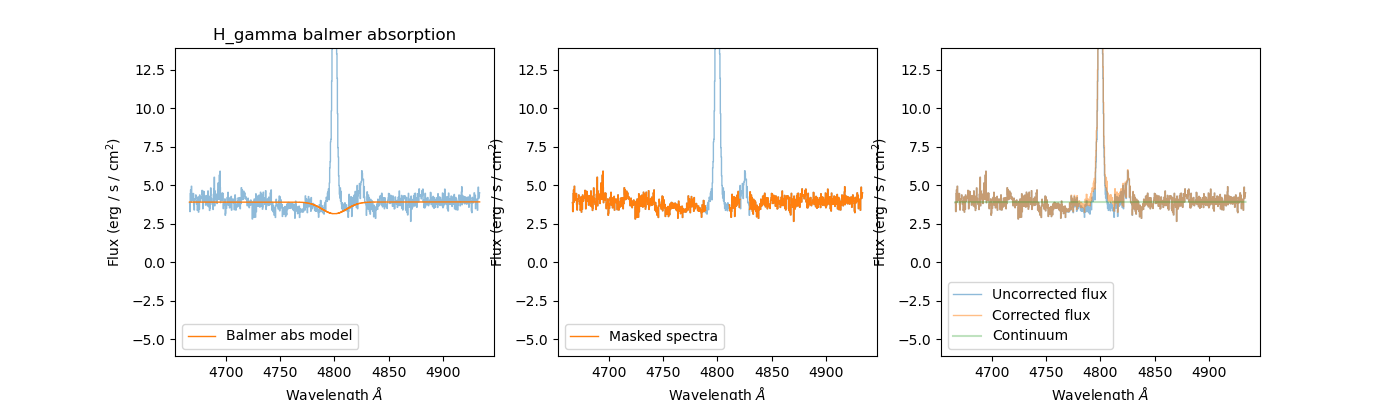

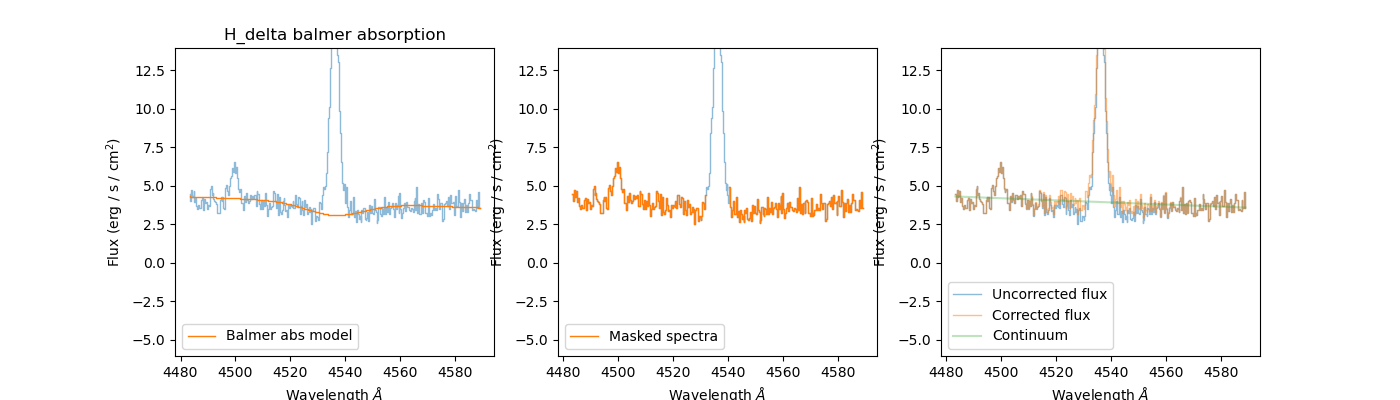

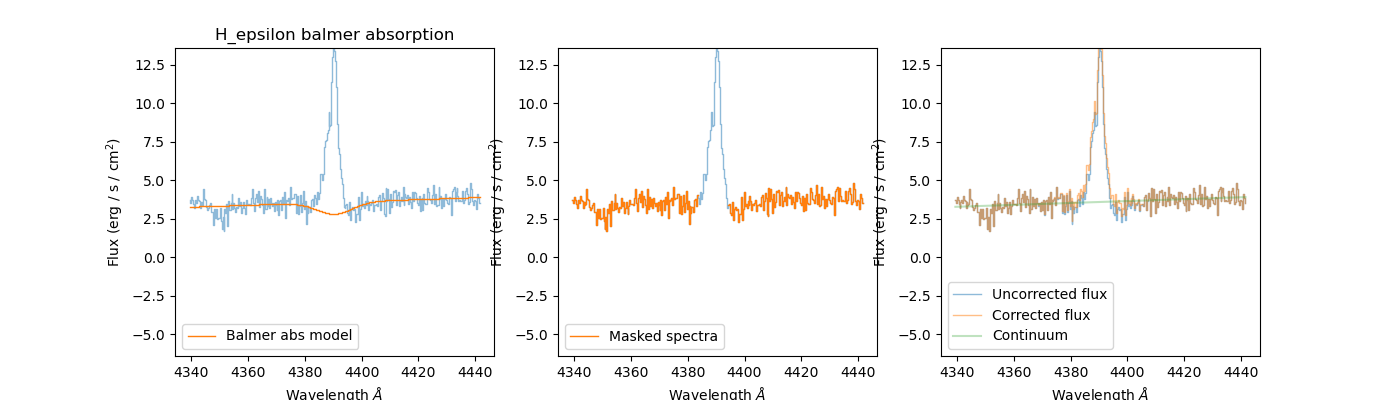

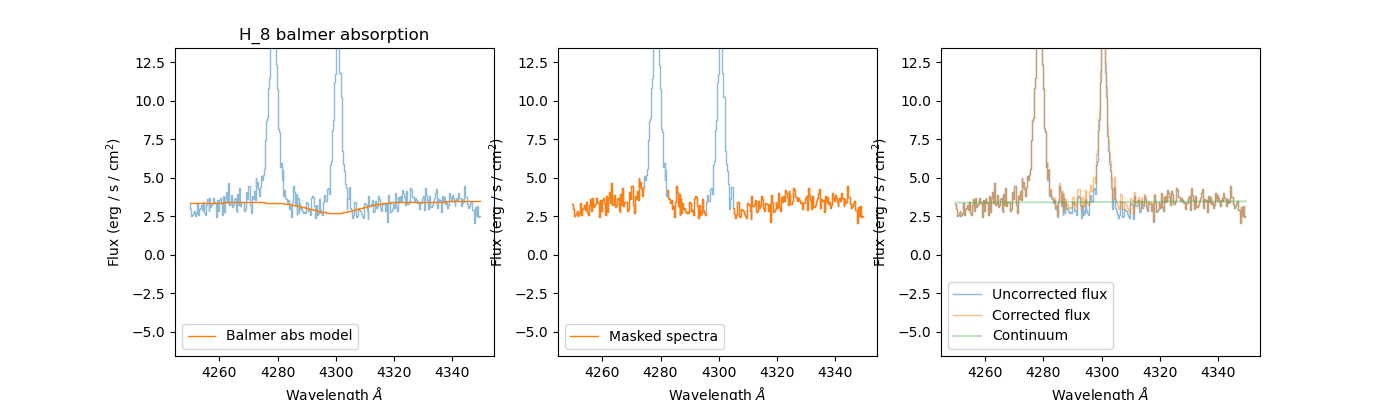

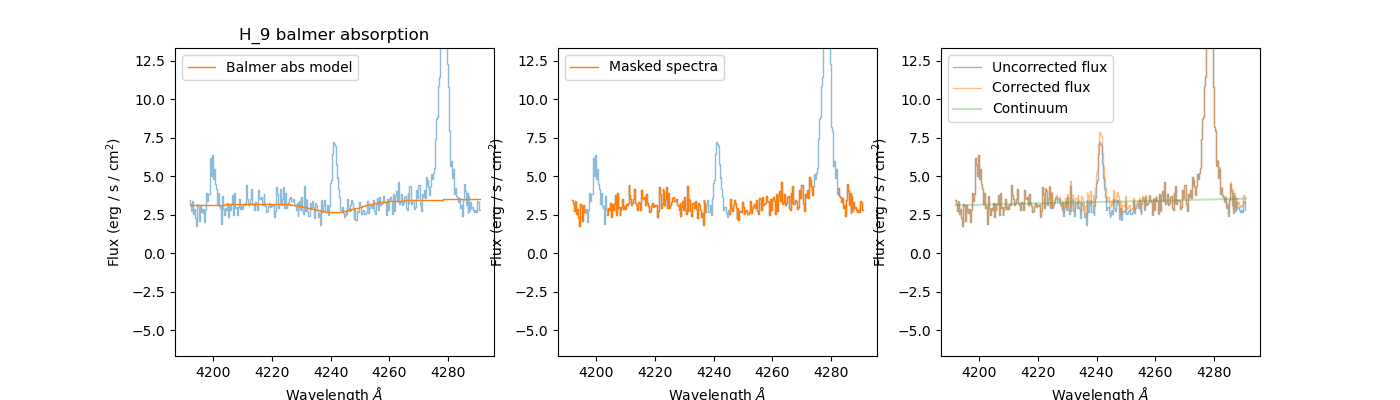

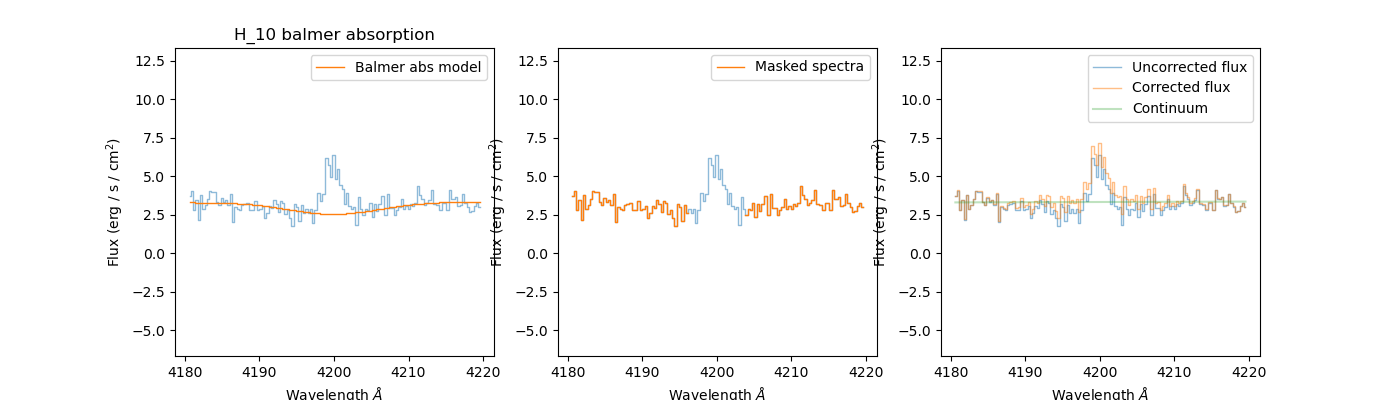

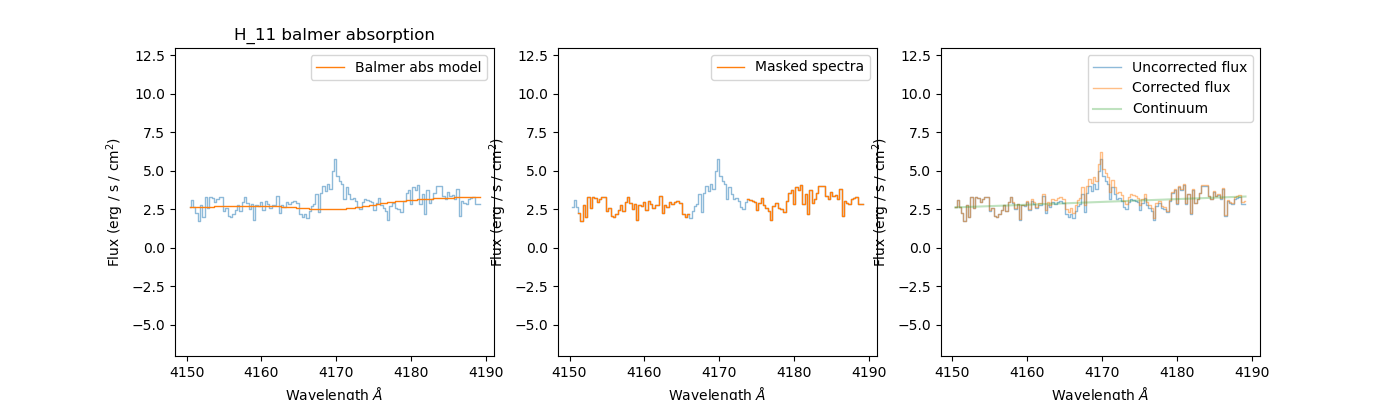

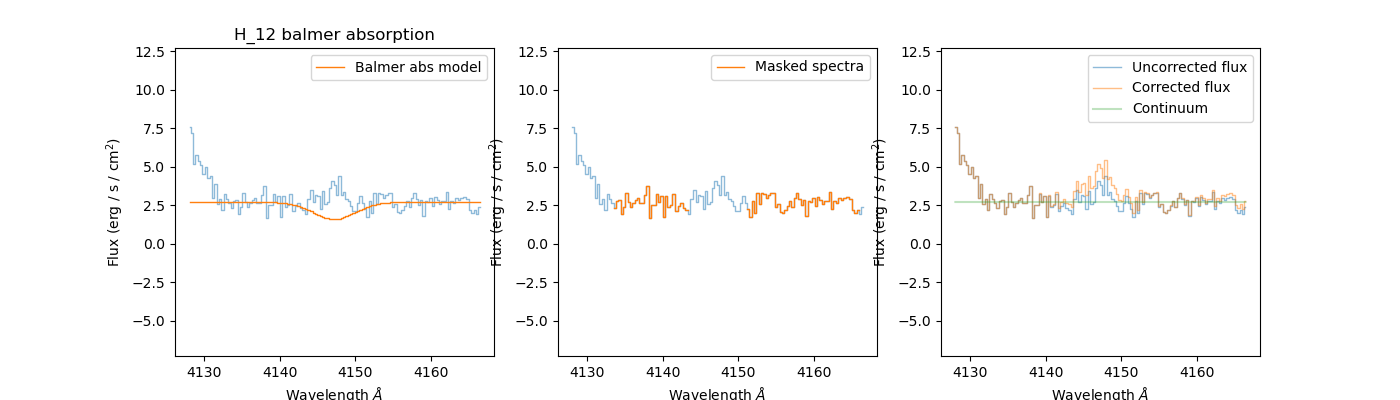

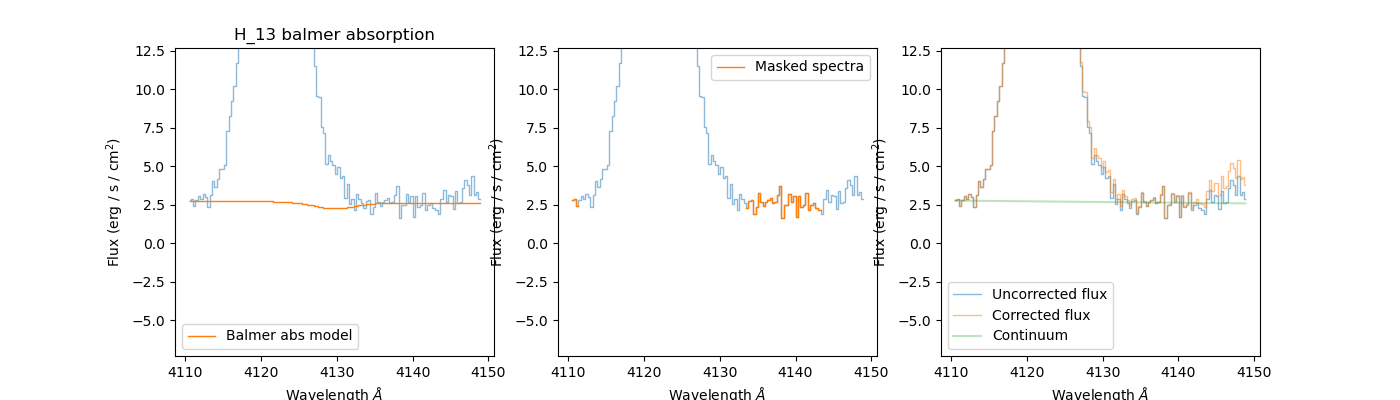

/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/corr.py:608: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  _, axs = plt.subplots(1, 3, figsize=(14, 4))


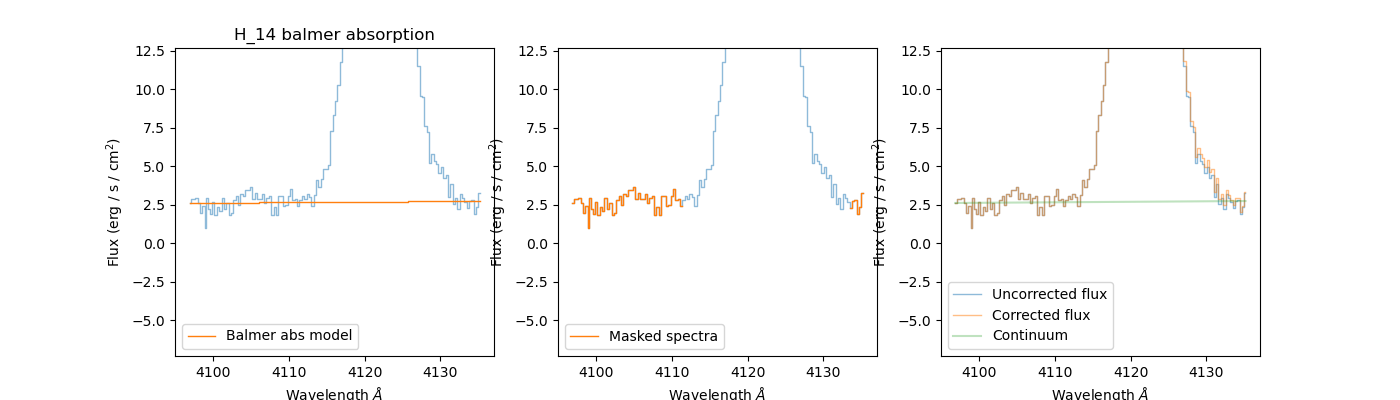

Using MW dust + Balmer abs corrected and continuum substracted data


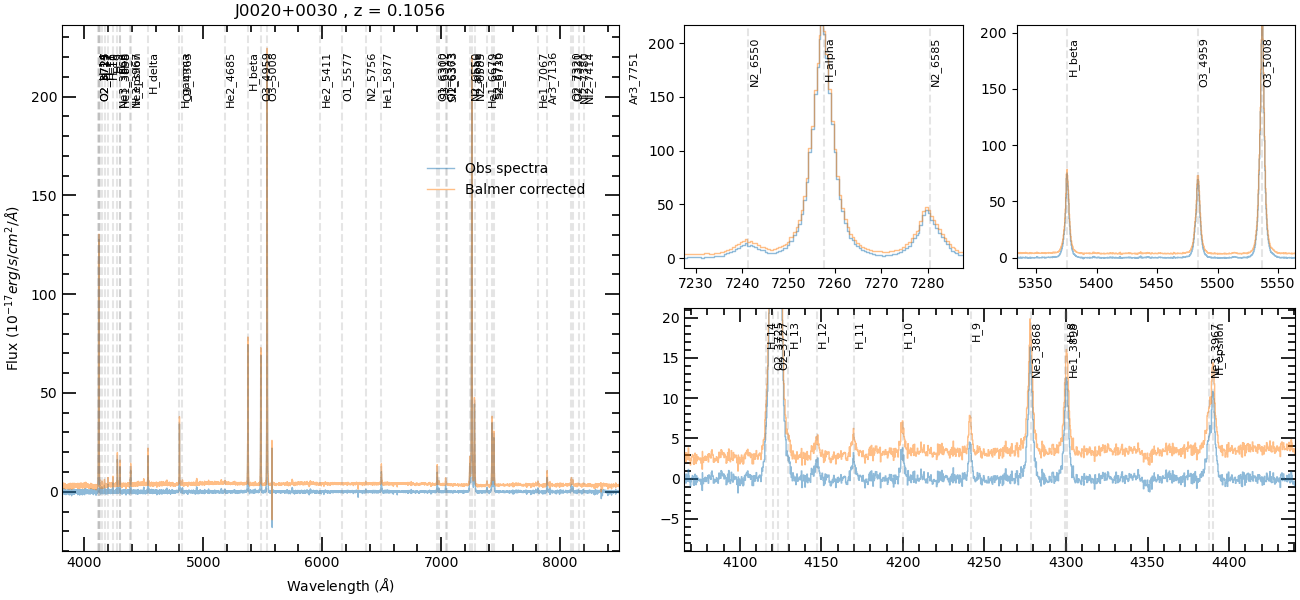

Saved Balmer Absorption corrected data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/bal_abs/bcorr_J0020.csv
Balmer absorption correction done!
Executed bal_abs_corr in 12.6003s


In [5]:
b = BALMER_ABS(J0020, showplot=True)


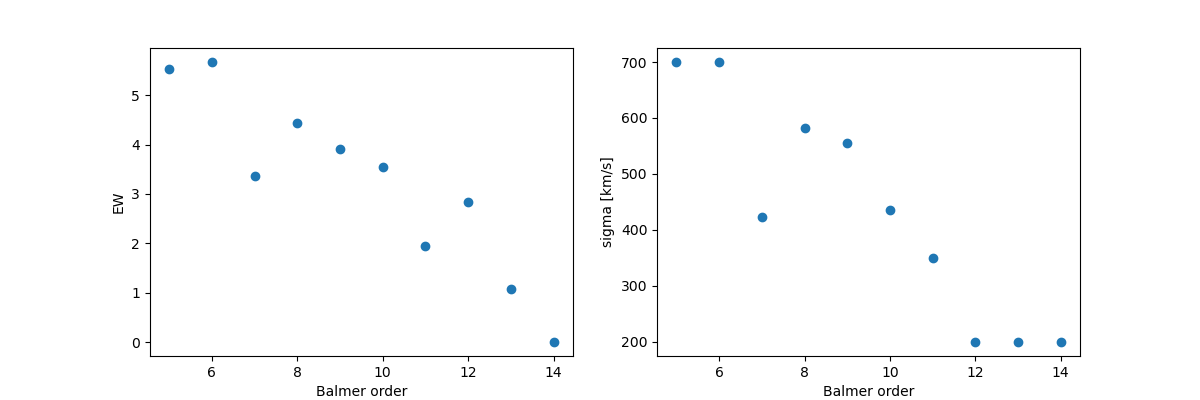

,ID,z,name,sigma,EW
0,J0020+0030,0.105563,H_beta,700.000000,-5.269847e+00
1,J0020+0030,0.105563,H_gamma,700.000000,-5.531773e+00
2,J0020+0030,0.105563,H_delta,700.000000,-5.671040e+00
3,J0020+0030,0.105563,H_epsilon,423.943035,-3.370486e+00
4,J0020+0030,0.105563,H_8,582.285592,-4.431159e+00
5,J0020+0030,0.105563,H_9,555.738494,-3.904556e+00
6,J0020+0030,0.105563,H_10,436.109701,-3.548027e+00
7,J0020+0030,0.105563,H_11,350.657240,-1.952706e+00
8,J0020+0030,0.105563,H_12,199.999776,-2.843003e+00
9,J0020+0030,0.105563,H_13,199.999813,-1.074144e+00


In [5]:
b.EW()

Reading data for J0020
Using MW dust + Balmer abs corrected  data


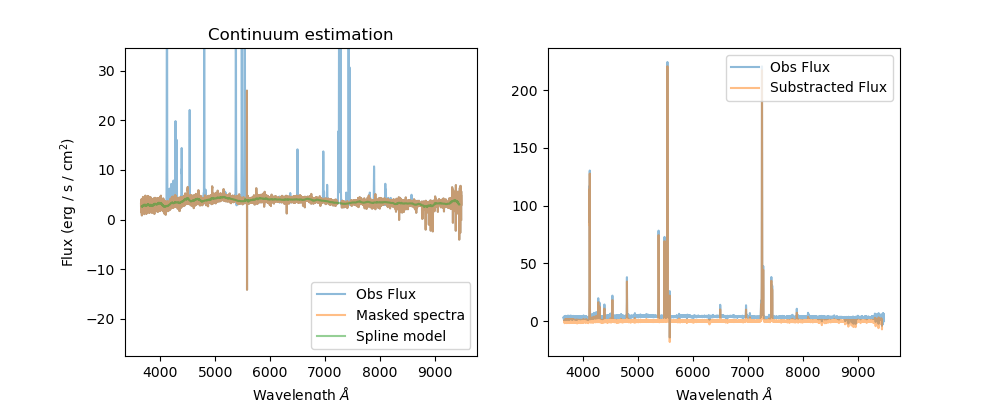

Executed cont_est in 0.3174s
Using MW dust + Balmer abs corrected and continuum substracted data


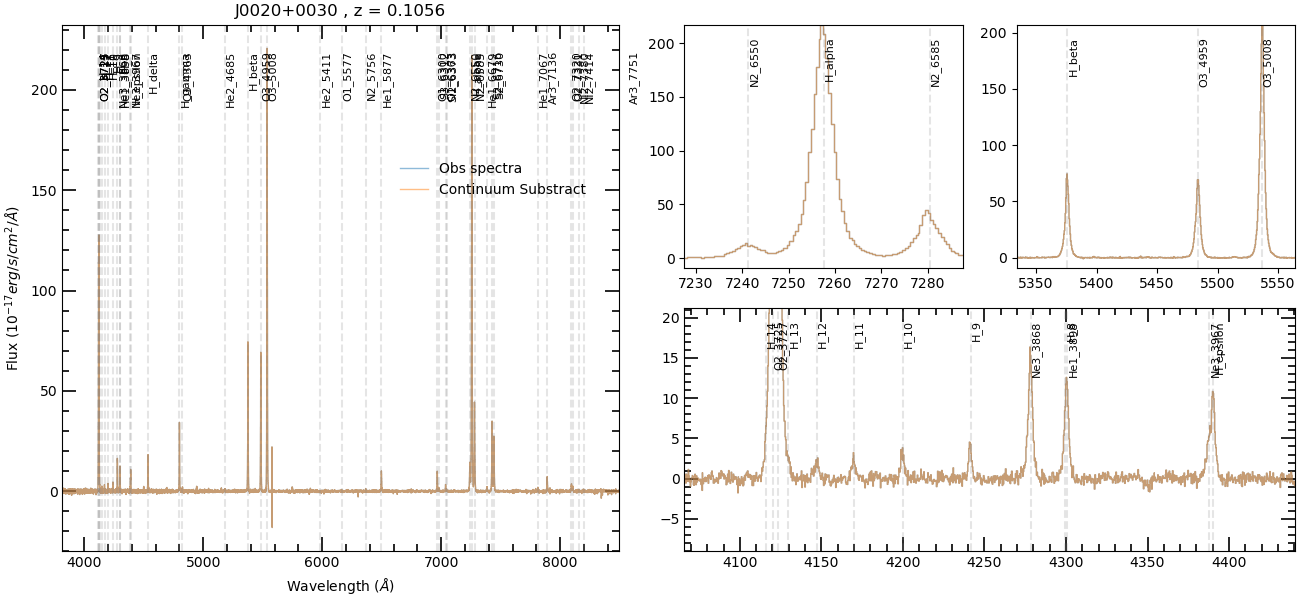

Saved continuum substracted data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/cont_subs/J0020/cont_corr_J0020.csv


In [5]:
CONTINUUM_SUBSTRACT(J0020)

Reading data for J0020
Using MW dust + Balmer abs corrected and continuum substracted data


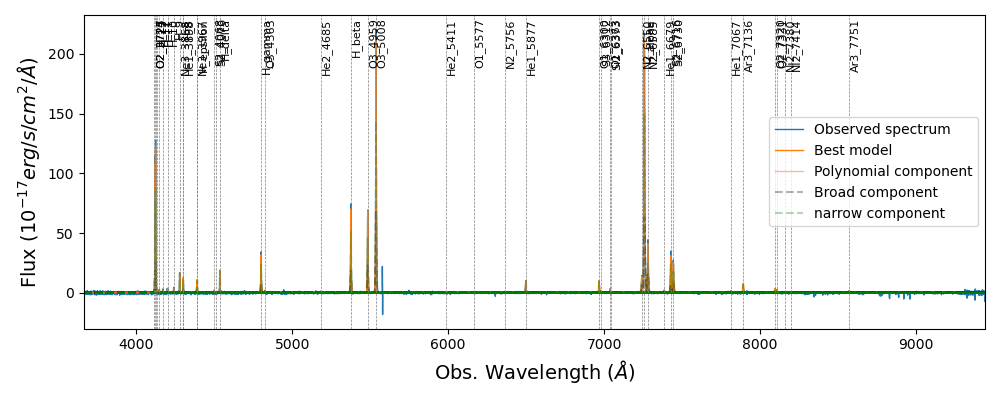

In [3]:
red = REDUC_LINES(J0020)
fit = red.fit_spectra(show_Plot=True)

In [7]:
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['H_alpha']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['H_beta']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['O3_5008']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['O3_4363']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['N2_6550']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['N2_6585']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))

4.017706962630746
2.9761025793142757
3.0651832590243107
2.6711596135600657
4.008697254708164
4.030368871011121


In [8]:
red.fit_MC(numMC=100)

Calculating the first initial params


KeyboardInterrupt: 

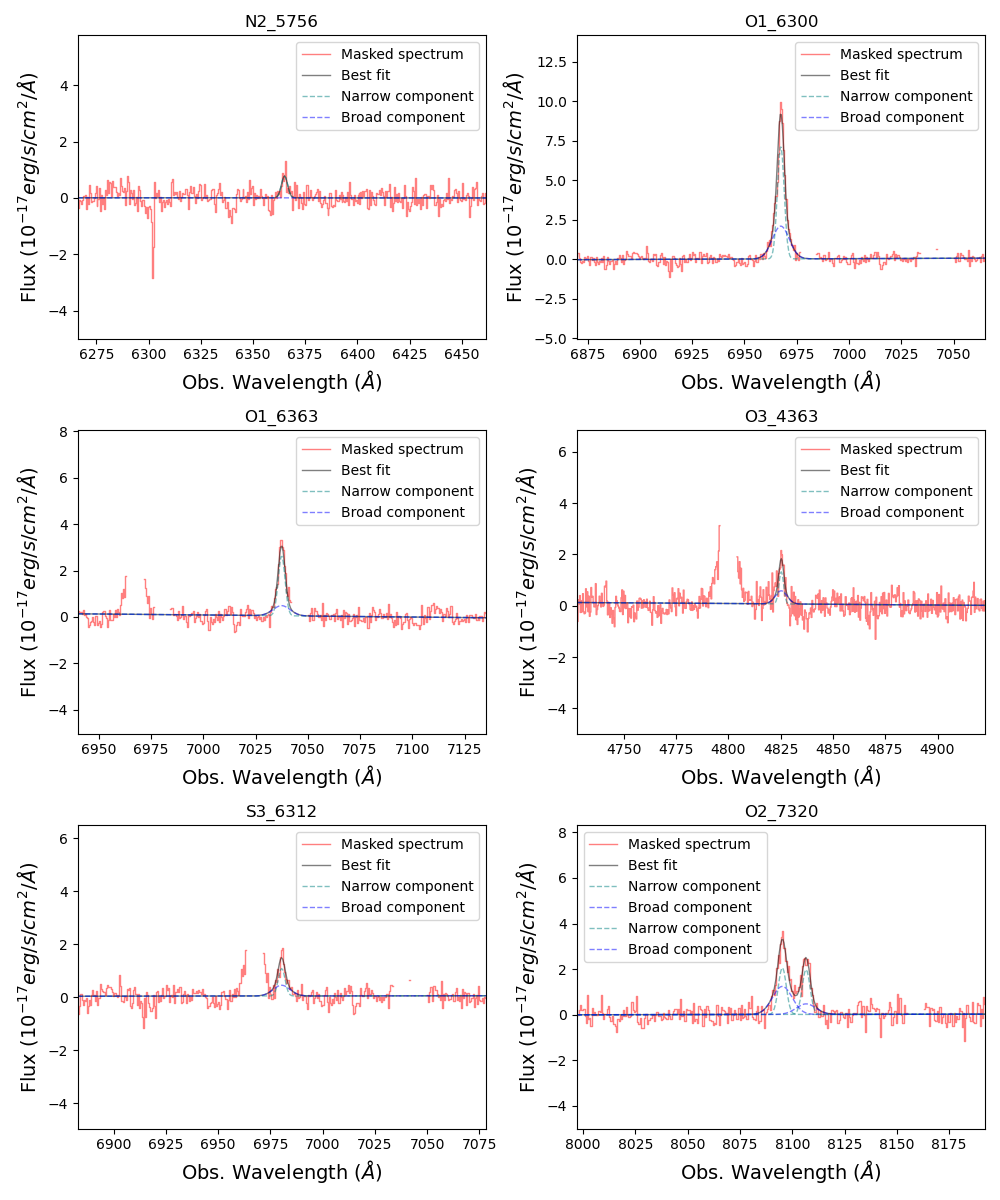

,sigma_v_narrow,sigma_v_broad,N2_5756_narrow_amplitude,N2_5756_broad_amplitude,O1_6300_narrow_amplitude,O1_6300_broad_amplitude,O1_6363_narrow_amplitude,O1_6363_broad_amplitude,O3_4363_narrow_amplitude,O3_4363_broad_amplitude,S3_6312_narrow_amplitude,S3_6312_broad_amplitude,O2_7320_narrow_amplitude,O2_7320_broad_amplitude,O2_7331_narrow_amplitude,O2_7331_broad_amplitude
0,69.995168,173.701538,2.873715,0.000034,29.118419,20.977539,10.633327,4.465078,3.52761,3.578526,4.232205,4.097514,9.727537,14.482509,9.339964,5.453467


In [9]:
red.fit_auroral(red.wave, red.flux, showplot=True)

In [6]:
df = red.fit_MC_auroral(numMC=100)

/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/lines.py:381: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  info = pd.concat([info, df], ignore_index=True)


Executed fit_MC_auroral in 17.1098s


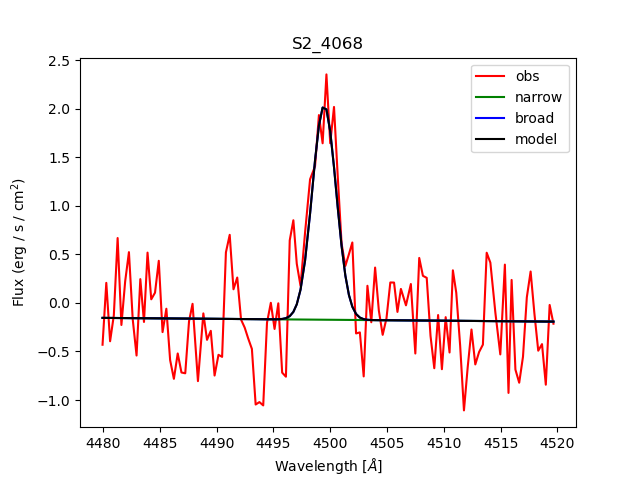

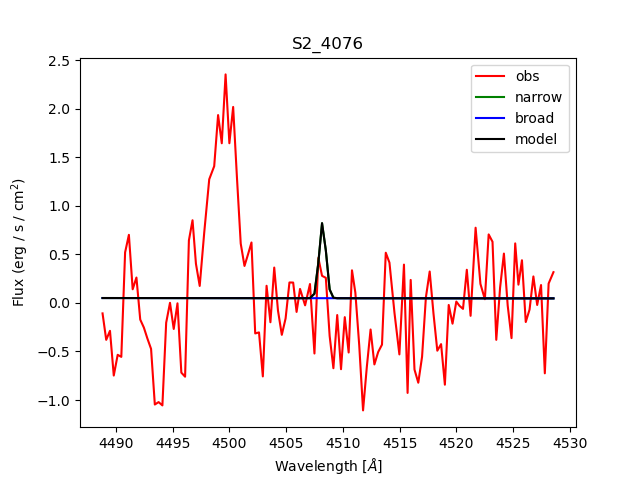

In [18]:
from astropy.io import fits
from lmfit.models import GaussianModel, PolynomialModel
from lmfit.parameter import Parameter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# get data
name= 'J0020'
save_path = f'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/cont_subs/{name}/cont_corr_{name}.csv'
dcorr = pd.read_csv(save_path)
wave, flux, sigma = dcorr['wave'], dcorr['flux'], dcorr['sigma']

# stamp
labels = 'S2_4068', 'S2_4076'
class_ = J0020
df = pd.read_csv(f'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/{name}/{name}_auroral_model.csv')
df = df[:-2]
for label in labels:
    wave_rest = class_.linelist_dict[label]
    wave_obs = wave_rest * (1 + class_.redshift)
    mask = ((wave > wave_obs - 20) & (wave < wave_obs + 20))
    wave_stamp, flux_stamp = wave[mask], flux[mask]
    sigma_stamp = dcorr['sigma'][mask]

    # model
    narrow_gaussian = GaussianModel(prefix=label+'_narrow_')
    broad_gaussian = GaussianModel(prefix=label+'_broad_')

    # Create a polynomial model for the continuum
    polydeg = 1
    polynomial = PolynomialModel(degree=polydeg)

    sum_of_gaussians = narrow_gaussian + broad_gaussian

    comp_mult = sum_of_gaussians + polynomial
    pars_mult = comp_mult.make_params()

    pars_mult.add(name='z', value=class_.redshift, vary=True)

    pars_mult.add(name='sigma_v_narrow', value=30, min=20, max=50)
    pars_mult.add(name='sigma_v_broad', value=60, min=50, max=70)

    for param in ['center', 'amplitude', 'sigma']:
        narrow_key = f'{label}_narrow_{param}'
        if param == 'center':
            value = wave_rest
            vary = True
            expr = f'{wave_rest:6.2f}*(1+z)'
        elif param == 'amplitude':
            value = 1
            vary = True
            expr = None
        elif param == 'sigma':
            vary = True
            expr = f'(sigma_v_narrow/3e5)*{label}_narrow_center'
        pars_mult[narrow_key] = Parameter(name=narrow_key, value=value,
                                            vary=vary, expr=expr,
                                            min=0.0)


    for param in ['center', 'amplitude', 'sigma']:
        broad_key = f'{label}_broad_{param}'
        if param == 'center':
            value = wave_rest
            vary = False
            expr = f'{wave_rest:6.2f}*(1+z)'
        elif param == 'amplitude':
            value = 0.3
            vary = True
            expr = None
        elif param == 'sigma':
            vary = True
            expr = f'(sigma_v_broad/3e5)*{label}_broad_center'
        pars_mult[broad_key] = Parameter(name=broad_key,
                                            value=value, min=0.0,
                                            vary=vary, expr=expr)

    for i in range(polydeg+1):
        pars_mult[f'c{i:1.0f}'].set(value=0)

    comps = []
    for i in range(100):
        y_off = flux_stamp + np.random.randn(len(flux_stamp)) * sigma_stamp
        out_comp_mult = comp_mult.fit(y_off, pars_mult, x=wave_stamp,
                                        nan_policy='omit', max_nfev=1000)
        comps.append(out_comp_mult)

    # plot 1
    model = comps[0].eval_components(x=wave_stamp)
    plt.figure()
    plt.plot(wave_stamp, flux_stamp, color='red', label='obs')
    plt.plot(wave_stamp, model[f'{label}_narrow_'] + model['polynomial'], color='green', label='narrow')
    plt.plot(wave_stamp, model[f'{label}_broad_'] + model['polynomial'], color='blue', label='broad')
    plt.plot(wave_stamp, comps[0].best_fit, color='black', label='model')
    plt.title(label)
    plt.xlabel(r"Wavelength [$\AA$]")
    plt.ylabel(r'Flux (erg / s / cm$^{2}$)')
    plt.title(label)
    plt.legend()
    plt.show()

    # Saving
    sum_narr = []
    sum_bro = []
    sum = []
    for comp in comps:
        sum_narr.append(comp.params[f'{label}_narrow_amplitude'].value)
        sum_bro.append(comp.params[f'{label}_broad_amplitude'].value)
        sum.append(comp.params[f'{label}_narrow_amplitude'].value + comp.params[f'{label}_broad_amplitude'].value)
    median_narr = np.median(sum_narr)
    std_narr = np.std(sum_narr)

    median_bro = np.median(sum_bro)
    std_bro = np.std(sum_bro)

    median = np.median(sum)
    std = np.std(sum)

    new_row ={
        'ID':df['ID'][0],
        'mass': df['mass'][0],
        'z':df['z'][0],
        'name':label,
        'flux':median,
        'fluxerr':std,
        'narrow_flux':median_narr,
        'narrow_fluxerr':std_narr,
        'broad_flux':median_bro,
        'broad_fluxerr':std_bro
    }
    df.loc[len(df)] = new_row
df.to_csv(f'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/{name}/{name}_auroral_model.csv')

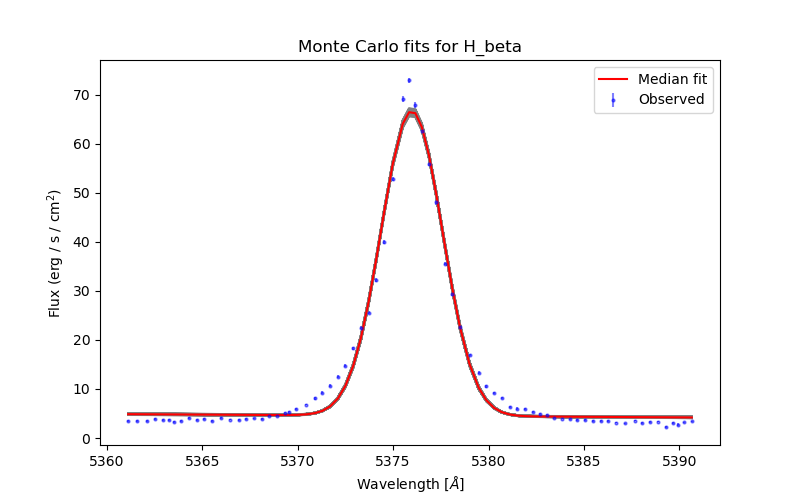

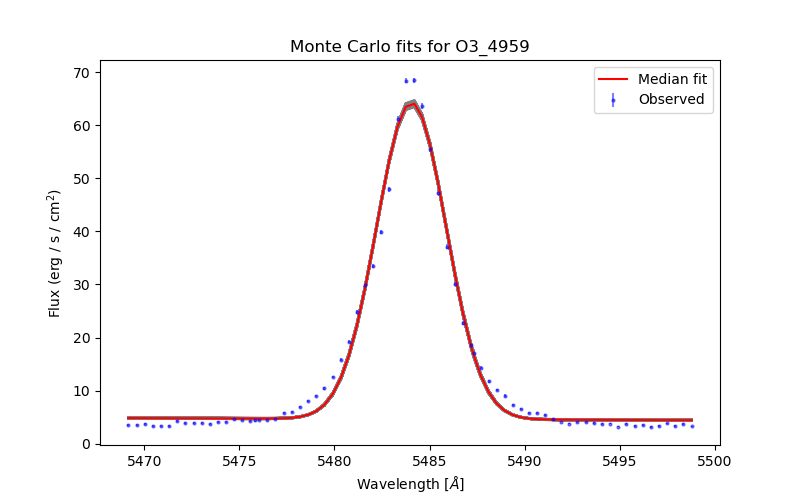

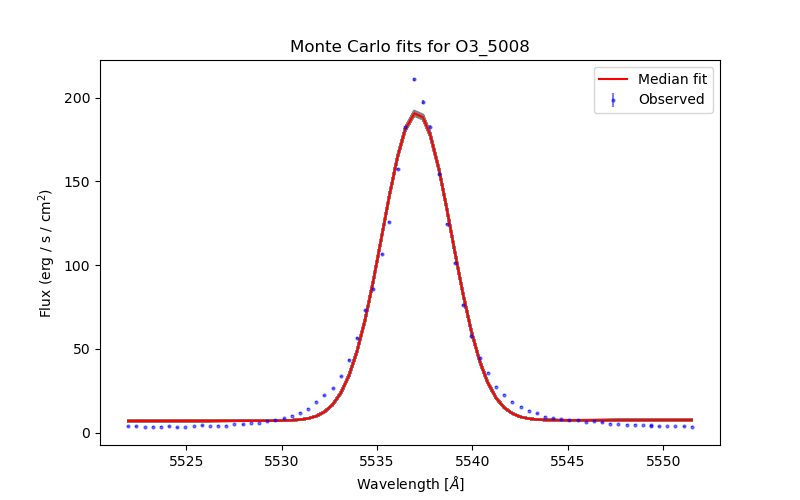

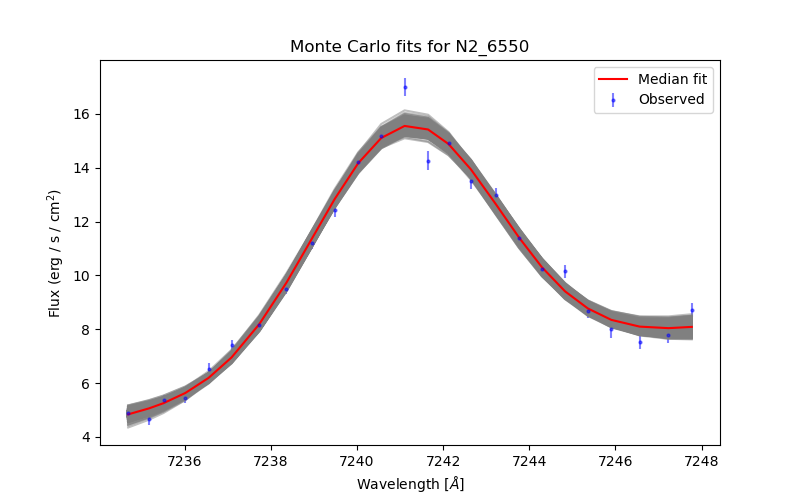

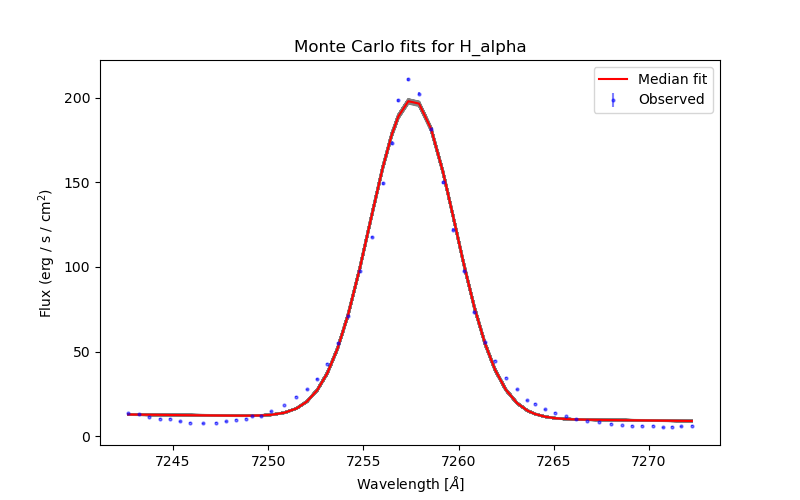

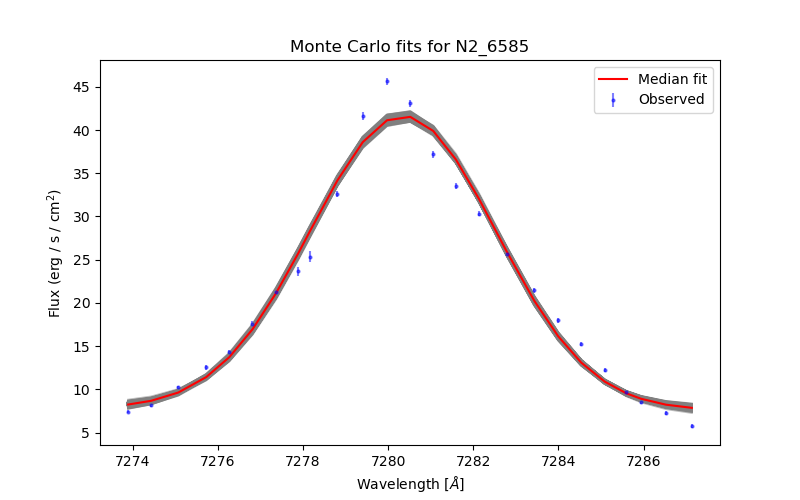

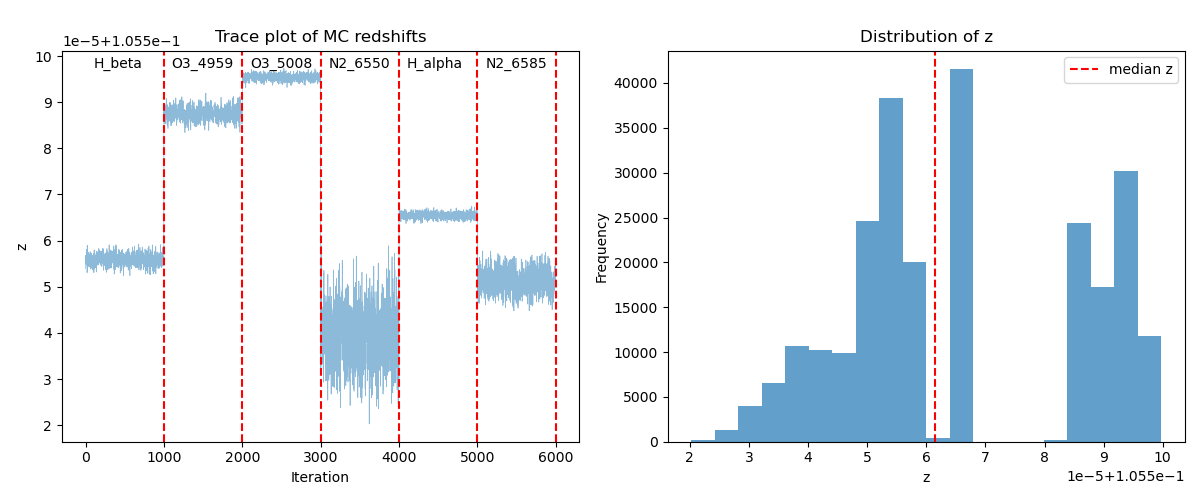

New redshift calculated for no_very_flats,z = 0.10556146827039448
Executed reset_redshift in 46.7963s
New redshift for J0020+0030,z = 0.10556146827039448
Reading data for J0020
Using MW dust + Balmer abs corrected and continuum substracted data
Starting MC iteration
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright

,ID,mass,z,name,flux,fluxerr,narrow_flux,narrow_fluxerr,broad_flux,broad_fluxerr
0,J0020+0030,9.6,0.105581,H_14,13.527817,0.882649,1.694546,0.790545,11.620281,1.441335
1,J0020+0030,9.6,0.105581,O2_3725,309.768955,1.853075,130.119688,2.840712,179.512650,3.750354
2,J0020+0030,9.6,0.105581,O2_3727,346.904439,1.402982,156.311204,3.059529,190.545917,3.436964
3,J0020+0030,9.6,0.105581,H_13,9.675568,0.568313,1.501985,0.720161,8.046995,1.082610
4,J0020+0030,9.6,0.105581,H_12,7.200869,0.440413,2.666799,0.169747,4.550529,0.280782
5,J0020+0030,9.6,0.105581,H_11,7.727607,0.430685,2.853751,0.159498,4.883461,0.283170
6,J0020+0030,9.6,0.105581,H_10,10.340012,0.430705,3.774135,0.175223,6.547167,0.277193
7,J0020+0030,9.6,0.105581,H_9,12.636863,0.504248,4.645869,0.211776,7.972047,0.318758
8,J0020+0030,9.6,0.105581,Ne3_3868,54.056218,0.636959,19.851594,0.407419,34.091830,0.549100
9,J0020+0030,9.6,0.105581,He1_3898,34.316812,0.940221,12.525331,0.416043,21.564990,0.627974


In [6]:
from fit_lines import save_data
J0020_SPECTRA= {
    'DIR':'/Users/javieratoro/Desktop/thesis/BAADE_DATA/testing/10-J0020/',
    'FILES': ['no_very_flats/J0020_NO_VERY_FLATS_tellcorr.fits'],
     'redshift': 0.106,
     'names':['J0020+0030'],
     'mass':9.6
}
save_data(J0020_SPECTRA, 100)